# Chapter 20: Industrial Control Systems and OT Security

> "In IT, a security incident costs money. In OT, a security incident can cost lives."

---


**On legal currency and jurisdiction.** Laws, regulations, and enforcement practices discussed in this chapter vary by jurisdiction and change over time. The descriptions here are for education and are not legal advice, and they may not reflect the latest amendments or local rules. Verify the current text of any law or regulation, and consult qualified counsel, before relying on it for a real decision. Instructors should review this material for currency each edition.

## Learning Objectives

After completing this chapter, you will be able to:

1. Distinguish operational technology (OT) from information technology (IT) and explain the convergence challenge.
2. Describe the components of an industrial control system: programmable logic controllers (PLCs),
   remote terminal units (RTUs), human-machine interfaces (HMIs), SCADA systems, and distributed
   control systems (DCSs).
3. Explain the Purdue Model and the ICS security zones it defines.
4. Describe the unique security challenges of OT environments: availability priority, legacy equipment, long lifecycles.
5. Apply IEC 62443 principles to OT security assessment.
6. Describe known ICS-targeted malware and their operational impact.
7. Explain NIST SP 800-82 guidance for industrial control system security.
8. Design a defense-in-depth architecture appropriate for an OT environment.
9. Decode an industrial protocol frame and explain why the design cannot authenticate its sender.
10. Compute a required safety integrity level from a layer of protection analysis, and state what
    that number does not account for.
11. Explain why active scanning is hazardous on a live OT network, and what passive monitoring can
    and cannot replace.


## Key Terms

- **OT**: Operational Technology; hardware and software that monitors or controls physical processes.
- **ICS**: Industrial Control System; the collective term for OT control systems.
- **SCADA**: Supervisory Control and Data Acquisition; monitors and controls geographically distributed processes.
- **DCS**: Distributed Control System; controls industrial processes within a single facility.
- **PLC**: Programmable Logic Controller; a ruggedised computer controlling physical actuators.
- **RTU**: Remote Terminal Unit; a field device collecting data from sensors and sending to SCADA.
- **HMI**: Human-Machine Interface; the operator console for viewing and controlling the process.
- **Engineering Workstation (EWS)**: laptop or PC used to program PLCs and update firmware.
- **Purdue Model**: hierarchical reference model for ICS network architecture.
- **Air gap**: physical separation between networks with no network connection.
- **IEC 62443**: international standard for industrial automation and control system security.
- **Stuxnet**: the first publicly documented cyberweapon targeting physical infrastructure.
- **BPCS**: Basic Process Control System; the system that runs the process in normal operation.
- **SIS / SIF**: Safety Instrumented System, and the Safety Instrumented Function it executes.
- **SIL**: Safety Integrity Level; the required performance band of a safety function.
- **PFDavg**: average probability of failure on demand; its reciprocal is the risk reduction factor.
- **MBAP header**: the seven-byte Modbus Application Protocol header that carries Modbus over TCP.
- **Zone and conduit**: an IEC 62443 grouping of assets by shared security requirements, and the
  controlled communication path between two groups.
- **Security level (SL)**: SL-T, SL-C and SL-A are the target, capability, and achieved security
  levels of IEC 62443.
- **NERC CIP**: the North American Electric Reliability Corporation (NERC) critical infrastructure
  protection standards, mandatory for the North American bulk electric system (BES).
- **Key switch**: the physical mode selector that permits or blocks logic changes on a controller.

---


## 20.1 IT Versus OT: A Fundamental Difference in Priorities

In IT, the CIA triad prioritizes Confidentiality first. In OT, the priority is inverted:
Availability and Integrity come first; Confidentiality is often secondary. A power plant
control system that goes offline to apply a patch causes a real-world outage. An unpatched
PLC that continues controlling a turbine is acceptable from the operations perspective; an
unavailable PLC is not. This fundamental difference means that IT security practices cannot
be directly transplanted to OT environments without adaptation.

### Safety as the Overriding Priority

OT security must consider physical safety consequences. A chemical plant process controller
that is manipulated by a threat actor could set temperatures or pressures outside safe
operating ranges, causing equipment damage or endangering workers. Safety instrumented
systems (SIS) provide independent protection layers designed to bring the process to a safe
state if dangerous conditions are detected.

---


## 20.2 ICS Components

### Programmable Logic Controllers

PLCs are the workhorses of industrial automation. They execute deterministic control logic
(scan-read inputs, execute ladder logic, write outputs) at cycle times measured in milliseconds.
PLCs are designed for 24/7 operation, harsh environments, and 20-30 year lifecycles. They were
designed for availability and functionality, not security: many PLCs have no authentication,
communicate over unauthenticated protocols (Modbus, DNP3 or Distributed Network Protocol 3, Profibus), and cannot be easily
patched without a maintenance window.

### SCADA Systems

SCADA systems collect data from widely distributed RTUs (substations, pumping stations, remote
sensors) over wide-area networks and provide centralized monitoring and control. The wide-area
connectivity that makes SCADA useful also creates an attack surface: SCADA communications may
traverse public networks, telecommunications infrastructure, or satellite links, each of which
represents a potential entry point.

### Human-Machine Interfaces

The HMI is the operator's view into the process. Operators issue commands and receive alarms
through the HMI. A compromised HMI can deceive operators by showing false process values while
the underlying process deviates from safe parameters -- exactly the technique used by Stuxnet,
which displayed normal centrifuge speed readings while commanding the centrifuges to spin at
damaging speeds.

---


## 20.3 The Purdue Model and Network Segmentation

The Purdue Model (also called the Purdue Enterprise Reference Architecture, PERA) organizes
ICS networks into hierarchical levels:

| Level | Name | Components |
|---|---|---|
| 0 | Field Level | Physical sensors, actuators, motors, valves |
| 1 | Control Level | PLCs, RTUs, safety systems |
| 2 | Supervisory Level | SCADA servers, DCS, HMIs |
| 3 | Manufacturing Operations | Historian servers, manufacturing execution systems (MES), engineering workstations |
| 3.5 | Industrial DMZ | Data diodes, jump servers, protocol converters |
| 4 | Business Logistics | Enterprise IT: enterprise resource planning (ERP), email, internet |

The levels are easier to hold as a walk through a factory than as a list. At the bottom are
the machines that physically move, then the controllers wired directly to them, then the room
where operators watch screens, then the plant's own scheduling and record keeping, and
finally the company offices, which are not in the plant at all. The level number is distance
from the thing that moves, and that ordering is what gives the model its safety meaning: a
failure at the bottom can injure somebody, while a failure at the top is expensive. The
separating layer between plant and offices, numbered 3.5 and usually called the industrial
demilitarized zone, is where most of the practical argument happens. Sources differ on the
top of the model, some stopping at Level 4 for the enterprise and others splitting it into a
Level 4 and a Level 5, so the number of the top level is a convention rather than a fact, and
this book uses Levels 0 to 4 plus 3.5 as the table above sets them out. The deeper limitation
is that the tidy hierarchy describes where traffic ought to flow and not where it does:
cellular modems on controllers and vendor remote access routinely connect the bottom to the
outside world without passing through any level in between, which Section 20.9 develops.

### The Industrial DMZ

The industrial DMZ (Level 3.5) is a critical security control: it mediates all communication
between the OT network (Levels 0-3) and the IT network (Level 4). Traffic should flow through
protocol-aware firewalls or data diodes (hardware devices allowing data flow in one direction
only). No direct connectivity should exist between the enterprise network and the control
network.

### Air Gaps and Their Limitations

An air gap (complete physical separation with no network connection) is the most secure
boundary between IT and OT. However, true air gaps are increasingly rare because business
requirements demand data from the plant floor (historian data for analysis, remote
diagnostics). Even an air-gapped network is vulnerable to removable media (Stuxnet spread
via USB), engineering workstations that connect to both networks, and vendor remote access.

---


## 20.4 OT-Specific Security Challenges

### Legacy Equipment and Long Lifecycles

OT equipment has lifecycles of 20-30 years. A PLC installed in 2000 may be running firmware
from that era, with no vendor support, no patches available, and no ability to install an agent.
The security controls applicable to a modern Windows endpoint (patching, AV, EDR) cannot be
applied to a legacy PLC. Compensating controls (network segmentation, monitoring at the protocol
level, application whitelisting on the engineering workstation) are required.

### Availability Requirements

Many OT processes cannot be interrupted: a nuclear power plant, a chemical reactor, or a water
treatment system cannot be rebooted to apply a patch. Maintenance windows are infrequent and
tightly controlled. Vulnerability management in OT requires coordination with operations,
risk acceptance for vulnerabilities that cannot be patched, and compensating controls.

### Protocol Insecurity

Industrial protocols were designed for reliability and determinism, not security. Modbus has
no authentication: any device that can send a valid Modbus command can control a PLC. DNP3
added authentication in DNP3 Secure Authentication v5, but deployment is limited. PROFINET
and EtherNet/IP are Ethernet-based and susceptible to standard network attacks. Protocol-aware
monitoring tools (Claroty, Dragos, Nozomi) can detect anomalous commands even without agent
deployment.

---


## 20.5 ICS Malware Case Studies

### Stuxnet (2010)

Stuxnet is widely considered the first publicly documented cyberweapon designed to cause physical
damage. It targeted Siemens S7-315 PLCs controlling Iranian uranium enrichment centrifuges,
commanding them to spin at damaging speeds while reporting normal operation to the SCADA system.
Stuxnet demonstrated that sophisticated OT attacks can achieve physical effects equivalent to
sabotage and that even air-gapped networks are not fully protected against insider or supply-chain
delivery of malicious code.

### Industroyer/CRASHOVERRIDE (2016)

Industroyer (also called CRASHOVERRIDE) was used against a transmission substation outside Kyiv
on 17 December 2016, cutting power to part of the city for about an hour. It implemented native
ICS protocol handlers for IEC 60870-5-101, IEC 60870-5-104, IEC 61850, and OPC (Open Platform
Communications) Data Access, allowing it to interact directly with power grid components without
requiring PLC-specific code. The larger figure of roughly 225,000 customers belongs to the
earlier December 2015 Ukraine attack, which was carried out by operators at a keyboard rather
than by malware; Section 20.14 separates the two.

### TRITON/TRISIS (2017)

TRITON targeted Schneider Electric Safety Instrumented System (SIS) controllers in a Middle
Eastern petrochemical facility. It attempted to disable safety systems, which would have allowed
dangerous process conditions to develop without triggering protective shutdowns. This attack
was the first publicly documented attempt to deliberately disable safety systems, with potential
consequences including explosion or toxic release.

---


## 20.6 IEC 62443 and NIST SP 800-82

### IEC 62443

IEC 62443 {cite}`iec_62443` is the international standard for industrial automation and control
system security. It defines: Security Levels (SL 0-4, from no requirements to protection against
state-level adversaries), zones and conduits (grouping components by security requirements and
managing communication between zones), and requirements for operators, integrators, and component
manufacturers.

### NIST SP 800-82

NIST SP 800-82 {cite}`nist_sp800_82` provides guidance specific to industrial control system
security, adapted from NIST 800-53 for the OT context. It acknowledges the unique OT constraints
(availability priority, legacy equipment, infrequent patching) and provides tailored control
baselines for ICS environments.

---


## 20.7 OT Defense-in-Depth

A layered OT security architecture applies the defense-in-depth principle across the Purdue levels:

- **Level 0-1**: physical security (locked cabinets, tamper-evident seals), network-level
  access control (only authorized engineering workstations can send configuration commands to PLCs).
- **Level 2-3**: protocol-aware firewalls (Modbus, DNP3, PROFINET inspection), passive monitoring
  and OT-aware intrusion detection (Chapter 12) that watch these protocols without disrupting them
  (anomalous commands, unusual data volumes), HMI hardening (application whitelisting, no internet
  access).
- **Level 3.5 (Industrial DMZ)**: data diodes for historian replication (one-way), jump servers
  with MFA for engineer access, protocol conversion (translate OT protocols to IT-safe formats).
- **Level 4**: standard IT controls on all enterprise systems; no direct connectivity to OT levels.

---
- **SCADA / DCS / PLC / RTU / HMI**: supervisory and field components of industrial control systems.
- **Modbus / DNP3 / PROFINET / OPC-UA**: OT protocols (mostly legacy/insecure; OPC-UA is securable).
- **Purdue model / IEC 62443 zones and conduits**: the reference segmentation model and OT-security standard.
- **Unidirectional gateway (data diode)**: hardware allowing data out of OT but no inbound connections.
- **Stuxnet / Industroyer / TRITON**: landmark ICS-targeting malware.

```{admonition} Knowledge Check
:class: tip
1. Why are legacy OT protocols such as Modbus and DNP3 inherently risky, and why is patching often not the
   answer?
2. What made Stuxnet and TRITON each a turning point in ICS security?
3. What is a unidirectional gateway (data diode), and why does it suit OT?

*Answers:* (1) They were designed for reliability without authentication or encryption, so commands can be read
or forged on the segment; many OT devices cannot be patched without halting a physical process and run
end-of-life software, so defense relies on segmentation and monitoring. (2) Stuxnet was the first malware to
cause physical destruction and to cross an air gap to PLCs; TRITON targeted a safety instrumented system,
raising the risk from disruption to human safety. (3) A device that physically permits data to flow only one
way (out of the OT network for monitoring) so inbound attacks are impossible, fitting OT's need to export
telemetry while preventing remote control.
```

## 20.8 OT Incident Response, Safety, and Resilience

Responding to an incident in operational technology differs fundamentally from IT incident response (Chapter
14), because the overriding priority is **safety and physical availability**, not data confidentiality. The
classic IT instinct, isolate and power off the affected host, can be dangerous in OT: abruptly stopping a
controller can leave a physical process (a furnace, a turbine, a chemical reaction) in an unsafe state, so
**containment must be coordinated with process and safety engineers** and may mean failing the process to a
known-safe condition rather than simply pulling the plug. Plants therefore maintain **manual fallback**
procedures so operations can continue safely without the compromised automation, and OT incident-response plans
are written jointly by security, operations, and safety staff and rehearsed in tabletop exercises (Chapter 14).

Several further realities shape OT defense. **Evidence collection** is constrained: many controllers have no
logging, limited memory, and cannot run endpoint agents, so investigators rely on network captures from the
passive monitoring described above and on engineering-station and historian data. **Patching** is governed by
maintenance windows that may occur only once or twice a year, so compensating controls (segmentation, virtual
patching at the firewall, strict access control) carry the load between windows. The attack surface is also
widening: industrial wireless, building-automation systems, smart-grid devices, and the broader Industrial
Internet of Things (IIoT) connect formerly isolated equipment, and remote-access pathways for vendors and
maintenance are a recurring entry point (the lesson of several documented intrusions). Finally, **safety
instrumented systems (SIS)**, the independent controllers of last resort, must remain isolated from the control
network, because, as the TRITON case showed, compromising the system meant to prevent catastrophe is the
worst-case scenario. The throughline of this chapter holds: in cyber-physical systems, security exists to
protect people and processes, so resilience, manual fallback, and safety-first response are the heart of OT
defense.

A final practical point ties OT security back to governance (Chapter 19) and risk (Chapter 5): because OT assets are long-lived, safety-critical, and expensive to take offline, securing them is as much an organizational discipline as a technical one. An accurate **asset inventory** (many breaches begin with an unknown or forgotten device), a clear ownership split between IT and OT teams, vendor and remote-access governance, and regular **risk assessments that explicitly weigh safety and physical consequences** are what turn the controls in this chapter into a sustained program rather than a one-time hardening exercise. The convergence of IT and OT means the two cultures must cooperate: IT brings security expertise, OT brings safety and process knowledge, and neither succeeds alone.

```{admonition} Knowledge Check
:class: tip
1. Why can the standard IT response of "isolate and power off" be dangerous in an OT incident?
2. Why is evidence collection harder on ICS devices than on IT endpoints?
3. Why must a safety instrumented system (SIS) remain isolated from the control network?

*Answers:* (1) Abruptly stopping a controller can leave a physical process in an unsafe state, so containment must be coordinated with process/safety engineers and may mean failing safely rather than powering off. (2) Many controllers have no logging, little memory, and cannot run endpoint agents, so investigators depend on network captures and historian/engineering-station data. (3) The SIS is the last-resort safeguard against physical catastrophe; if it shares the control network it can be compromised together with the process it protects, exactly the TRITON scenario.
```


## 20.9 Why OT Networks Stay Flat

Section 20.3 introduced the Purdue model as though drawing the levels were most of the work. Almost
every plant already has a diagram with six tidy boxes on it. What the diagram usually does not show
is that inside Levels 0 through 3 everything can reach everything else, and that this is not laziness
or an unfinished backlog item. Flatness in an OT network is normally the residue of decisions that
were correct when they were made, and an assessor who treats it as negligence will propose a
segmentation project that operations refuses, without ever learning why.

### Four reasons the flatness is load bearing

**The protocols assume a shared segment.** PROFINET real-time traffic and EtherNet/IP implicit
messaging carry cyclic process data, meaning a controller and its input and output modules exchange
the same short frame every cycle, at cycle times that can be a few milliseconds, often over multicast
(the Internet Assigned Numbers Authority registers EtherNet/IP input and output to port 2222 and
PROFINET real-time multicast to 34963). Neither survives a routed boundary without care: a router
adds latency and jitter to a timing budget engineered without them, and multicast across a routed
boundary needs group management configuration the automation vendor never tested.

**The vendor's support contract assumes the shipped architecture.** A packaged skid, a turbine
control system, or a safety system is commissioned as a validated assembly. Inserting a firewall
into the middle of it is a change to that assembly. In a regulated plant it may trigger a formal
management of change process, and in almost any plant it gives the vendor a reason to point at the
firewall when the line stops. The technical objection is sometimes weak. The contractual one rarely
is.

**There is no window in which to do the work.** A controller's address usually lives inside its
project file, so changing it means editing the project and downloading it, which means stopping the
controller and therefore the process. A plant with two short outages a year spends them on mechanical
work queued for months. Network redesign competes with a bearing replacement and loses.

**The systems that want data want it from everywhere.** The historian collects tags from every
controller. The engineering workstation must reach every controller it programs. The alarm server,
the batch server, and the asset management system each need a path to most of the floor. Every one
of those is a legitimate flow, and every one, drawn honestly, crosses the tidy boxes.

### What the Purdue model assumes, and what breaks it

The Purdue hierarchy encodes an assumption: that traffic is hierarchical, that a flow crosses one
level at a time, and that a device's security requirements follow from its physical position in the
plant. Two modern additions break that assumption without anyone deciding to break it.

A cellular modem at a remote pump station gives a Level 1 device a direct path to a public network,
bypassing Levels 2, 3, and 3.5 entirely; the FBI and the Environmental Protection Agency named
exactly this pattern in a public service announcement dated 30 July 2026, recommending that such
modems be secured with strong authentication and that their logs be enabled and reviewed. A
cloud-connected condition monitoring sensor, meanwhile, sits physically at Level 0 and logically at
Level 4, and a vendor analytics platform pulling process data over an outbound connection does not
appear on the diagram at all, because the diagram predates it.

The model is not obsolete, and its levels remain the clearest shared vocabulary a network engineer
and a control engineer have. But the levels are a starting partition, not an answer. IEC 62443,
covered in Section 20.12, replaces the physical hierarchy with zones defined by shared security
requirements and conduits defined by the flows that must cross between them. A cellular-connected
pump station is then its own zone with its own conduit, which is a statement the Purdue diagram
cannot make.

### Where to start when you cannot re-architect

The sequence plants actually complete, in order, is: build an asset inventory (Section 20.15 explains
why it cannot be built by scanning); draw the flows that exist rather than the flows the diagram
claims; put a firewall at the Level 3 to Level 4 boundary; move remote access behind a broker
(Section 20.16); and only then argue about segmenting the process network itself. Each step is
defensible on its own, which is what makes each one fundable.


## 20.10 The Protocols, and Why the Old Ones Cannot Authenticate Anything

Section 20.4 stated that industrial protocols have no authentication. That claim is worth proving
rather than asserting, because the shape of the proof decides which defenses can work. If the problem
were weak authentication you could strengthen it. The actual problem is that there is no field in the
message where authentication could go and no state in the device where a key could live.

### Modbus, byte by byte

Modbus was published by Modicon in 1979 for a serial link between a controller and a few devices, on
wire the plant owned and could see. Its modern form, Modbus TCP, wraps the same message in a
seven-byte Modbus Application Protocol (MBAP) header and sends it to TCP port 502, which the Internet
Assigned Numbers Authority registers to modbus.org under the service name mbap.

Here is a complete and valid Modbus TCP request that turns on a single output:

```
00 01   00 00   00 06   01   05   00 0A   FF 00
```

```{image} ../../assets/figures/ch20_modbus_frame.png
:alt: The twelve bytes of a Modbus TCP write request laid out in order. Transaction identifier 00 01, protocol identifier 00 00, length 00 06, unit identifier 01, function code 05 Write Single Coil, output address 00 0A, output value FF 00 meaning ON. A second row marks that no field carries identity, integrity, or freshness.
:width: 96%
:align: center
```

Reading left to right, the first seven bytes are the MBAP header and the last five are the protocol
data unit:

- `00 01` is the transaction identifier, echoed in the response so a client can match replies to
  requests.
- `00 00` is the protocol identifier, which is always zero for Modbus.
- `00 06` is the length field, the count of the bytes that follow it: one unit identifier, one
  function code, and four data bytes.
- `01` is the unit identifier, which addresses a device behind a gateway.
- `05` is the function code, Write Single Coil.
- `00 0A` is the output address, coil ten.
- `FF 00` is the value. The specification permits exactly two values in this field: `FF00` requests
  the coil ON and `0000` requests it OFF. The normal response is an echo of the request, returned
  after the coil state has been written.

Now count what is absent. There is no identity field, no key identifier, no message authentication
code, no nonce, and no session. The transaction identifier pairs responses with requests and proves
nothing about the sender, and an attacker picks it as freely as the client does. Twelve bytes, every
one a value any host on the segment can construct, and a receiving device with no mechanism by which
it could decline them. That is why the defense for Modbus is never "authenticate the traffic" and
always "control who can put a frame on this segment, and watch which frames appear."

Two further properties matter. The specification caps the Modbus TCP application data unit at 260
bytes, a 253-byte protocol data unit plus the 7-byte header, so a Modbus conversation is a long
stream of tiny messages; volume-based anomaly detection therefore works poorly and command-based
detection works well, which is why OT monitoring products are sold as protocol-aware rather than as
flow analyzers. And function code `08`, Diagnostics, defines for serial line devices a sub-function
`04`, Force Listen Only Mode, which instructs a device to stop responding: a specification-compliant
way to silence a device is part of the protocol.

### The rest of the family

| Protocol | Usual transport | Authentication in the base design | Secured option |
|---|---|---|---|
| Modbus TCP | TCP 502 | None | Modbus/TCP Security over TLS, registered as `mbap-s` on port 802 |
| DNP3 | TCP or UDP 20000 | None | DNP3 Secure Authentication v5, in IEEE 1815-2012 |
| IEC 60870-5-104 | TCP 2404 | None | IEC 62351 security services |
| IEC 61850 MMS (Manufacturing Message Specification) | TCP 102 | None | IEC 62351 security services |
| EtherNet/IP | TCP 44818 explicit, UDP 2222 implicit | None | CIP Security, TLS and DTLS on port 2221 |
| PROFINET | Ethernet and UDP 34962 to 34964 | None in the original design | PROFINET Security Classes, ports 34965 and 34966 registered in 2026 |
| OPC UA | TCP 4840 | Built in | Message security modes Sign and SignAndEncrypt |

**DNP3 Secure Authentication** shows what it costs to bolt authentication onto a protocol that
shipped without it. Version 5, defined in Clause 7 of IEEE 1815-2012, is a challenge and response
layer: the receiver challenges a request the configuration marks as critical, the sender answers
with a message authentication code computed over the request and the challenge, and only then is the
request executed. Because a challenge exchange doubles the round trips on a link that may be a slow
radio circuit, the standard also defines an aggressive mode in which the sender carries its
authentication data with the original request. Note the boundaries of what this buys: it
authenticates, it does not encrypt, and it covers only the messages configured as critical. It is a
retrofit and it reads like one, which is part of why deployment has lagged.

**OPC UA** is the one member of the family designed after the threat was understood. Standardized as
IEC 62541 and registered at TCP port 4840, it defines three message security modes: None, which
transfers plain text; Sign, which adds a digital signature; and SignAndEncrypt, which does both, with
clients and servers authenticating each other by X.509 application instance certificates. The caution
is that None is valid and easiest to make work. The joint advisory issued in April 2022 by the
Department of Energy, CISA, the National Security Agency, and the FBI described an attacker module
whose whole function was to connect to improperly secured OPC UA servers using default or
compromised credentials and read the server's structure, and its mitigations included configuring
OPC UA security with application authentication enabled and explicit trust lists. A securable
protocol deployed insecurely is not safer than Modbus. It is Modbus with more code.

### Why the old designs cannot simply be fixed

Three constraints, none of them ignorance, produced protocols with no authentication.

The threat model was physical. A serial multidrop line inside a fenced plant was authenticated by
the fence, the locked cabinet, and the conduit, and for the plant's whole design life that was true.

The scan cycle had no spare budget. A controller runs a fixed loop, and the loop must finish inside
its cycle time or the controller faults. Computing a cryptographic message authentication code per
message did not fit that budget in 1979 and does not fit it on much of the equipment still running.

The installed base cannot be recalled. A protocol change field devices cannot execute is not an
upgrade; it is a replacement program with a twenty-year horizon and a capital cost. That is why every
secured variant in the table coexists with the original rather than replacing it, and why the
defenses in the rest of this chapter are architectural rather than cryptographic.

### Exercises

1. In the frame `00 01 00 00 00 06 01 05 00 0A FF 00`, which field must an attacker forge for the
   write to succeed, and what is the significance of the answer?
2. Why does DNP3 Secure Authentication define an aggressive mode, and what does that mode give up?
3. A plant reports that it has migrated to OPC UA and therefore no longer needs segmentation. Give
   the two-sentence rebuttal.
4. Give one design reason and one economic reason that Modbus still has no authentication.

### Answer Key

1. None of them. There is no identity, key, or integrity field, so a syntactically valid frame from
   any host on the segment is indistinguishable from a legitimate one. No protocol-level effort helps,
   so the control has to be on reachability and on detecting anomalous commands.
2. Because a separate challenge costs an extra round trip on links that may be slow serial or radio
   circuits. What it gives up is a challenge generated for that specific message, so freshness rests
   on state carried forward from an earlier exchange.
3. OPC UA is securable, not secure by default, and mode None is both valid and easiest to get
   working. Federal advisories describe attacker tooling that connects to improperly secured OPC UA
   servers with default or compromised credentials.
4. Design: the scan is a fixed loop that must finish inside its cycle time, and per-message
   cryptography did not fit. Economic: the installed base is measured in decades, so a change field
   devices cannot execute is a replacement program rather than an upgrade.


## 20.11 Safety Instrumented Systems, and Where Safety and Security Collide

Section 20.1 said that safety overrides security in OT. That is true and not the whole story, because
safety is not a slogan in a plant. It is an engineered quantity with its own standards, arithmetic,
and equipment, and once you can read that arithmetic you can see where a security control helps it
and where one damages it.

### The problem an independent layer solves

The system that runs the process is the basic process control system, or BPCS: the loop that holds a
tank level at setpoint by modulating a valve. It will eventually fail, because everything does, and
if the only thing between a failure and a rupture were the system that failed, the plant would have
no defense at all.

So plants build layers of protection, each independent of the ones around it. A common ordering, from
the process outward, is: the BPCS control loop; an alarm and an operator with time to act on it; the
safety instrumented system, which trips the process automatically; a mechanical relief device such as
a rupture disc, which needs no electricity and no logic; and finally physical containment such as a
dike or a flare. A layer is credited only if it is genuinely independent of the others, which is the
whole reason the ordering exists.

```{image} ../../assets/figures/ch20_protection_layers.png
:alt: Layers of protection around a process, drawn as nested bands. Innermost the process, then the basic process control system loop, then alarm and operator response, then the safety instrumented system, then mechanical relief, then physical containment. A side note marks that the safety instrumented system is the last programmable layer and the last one an attacker can reach over a network.
:width: 92%
:align: center
```

The **safety instrumented system**, or SIS, is a separate controller executing **safety instrumented
functions**, or SIFs. A SIF is a complete chain: a sensor that detects the dangerous condition, a
logic solver that decides, and a final element such as a shutdown valve that acts. IEC 61511-1, the
process sector standard, requires in clause 11.2.4 that the BPCS be designed to be separate and
independent from the SIS to the extent that the functional integrity of the SIS is not compromised.
That clause is a safety requirement that happens to also be the single most important security
control in the plant.

### The arithmetic, with real numbers

Each SIF is assigned a **safety integrity level**, SIL 1 through SIL 4. For a function that acts only
on demand, the measure is the average probability of failure on demand, PFDavg, and the reciprocal of
PFDavg is the **risk reduction factor**, RRF.

| SIL | PFDavg (low demand mode) | Risk reduction factor |
|---|---|---|
| 1 | at or above 0.01 and below 0.1 | 10 to 100 |
| 2 | at or above 0.001 and below 0.01 | 100 to 1,000 |
| 3 | at or above 0.0001 and below 0.001 | 1,000 to 10,000 |
| 4 | at or above 0.00001 and below 0.0001 | 10,000 to 100,000 |

Work a tank overfill through it. Suppose a layer of protection analysis puts the frequency of the
initiating event, a level controller failing with the fill valve open, at 0.25 per year, or once in
four years. Suppose the plant's tolerable frequency for a release of this size is 0.00001 per year,
or once in 100,000 years. The total risk reduction needed is

$$\text{RRF}_{\text{total}} = \frac{0.25}{0.00001} = 25{,}000 .$$

Two independent protection layers already exist. The BPCS high-level loop is credited with an RRF of
10, which is the ceiling IEC 61511 allows for a BPCS layer unless the BPCS itself is designed and
managed to the standard. A high-level alarm with a documented operator response is credited with
another 10. Together they supply

$$\text{RRF}_{\text{existing}} = 10 \times 10 = 100 .$$

What is left for the safety instrumented function is

$$\text{RRF}_{\text{SIF}} = \frac{25{,}000}{100} = 250, \qquad
\text{PFD}_{\text{avg}} \le \frac{1}{250} = 0.004 .$$

A PFDavg of 0.004 sits inside the SIL 2 band, so this is a SIL 2 function. That single number now
governs the sensor's diagnostic coverage, the redundancy of the logic solver, the valve's stroke
testing interval, and the proof test schedule for the next twenty years.

Now read the number as a security engineer. Every term in it describes random hardware failure over
time. Nothing in it describes an adversary. PFDavg assumes failures are independent, random, and
uncorrelated, and an attacker is none of those things: an attacker fails every channel at once, on
purpose, at the moment of maximum consequence. The certificate on the logic solver is a statement
about component reliability. It is not a statement about anyone trying.

Redundancy in a SIF is written as M out of N. A **1oo1** function is a single channel. A **1oo2**
function trips if either channel demands it, which is safer and produces more spurious trips. **2oo3**,
the triple modular redundant arrangement used by controllers such as the Triconex family, trips when
any two of three channels agree, improving both numbers at once. The point for a security engineer is
that availability and safety already trade against each other inside the safety system, so a request
for change joins an argument that has been running for decades rather than starting one.

### Five places the two disciplines actually collide

**The key switch.** Safety controllers have a physical mode switch. In RUN, logic cannot be changed.
In PROGRAM, it can. CISA's malware analysis report on the TRITON malware records that the malware
requires the Tricon key switch to be in the PROGRAM position to deploy its payload successfully, and
the FBI and Environmental Protection Agency (EPA) advisory of 30 July 2026 recommends placing physical and software key switches in the
run position and returning them there immediately after any download. The security answer is
obvious. The operational objection is equally real: someone must walk to the cabinet, and at an
unstaffed remote site nobody can.

**Patching.** A certified safety controller is certified against a specific firmware version, so
applying a patch can require re-validation of the safety function, which is documented and slow.
Section 20.16 gives a recorded case in which the patch itself was the hazard. Patching is not
automatically the safe choice.

**Passwords and integration.** Requiring a login at an operator console is standard IT practice, and
in a control room during an upset the seconds at a login prompt are seconds not spent on the process;
the usual resolution is to authenticate the workstation and the network path strongly and leave the
console session open in a physically controlled room. Separately, vendors sell integrated control and
safety systems that share an engineering environment, a network, and sometimes a chassis, because one
environment is cheaper to engineer. Each shared element erodes the independence that clause 11.2.4
asks for, and erodes it for the attacker at the same time as for the engineer.

**Remote access to the safety system.** The person who understands the safety logic is rarely on
site, which is a good reason to want it. TRITON, covered in Section 20.14, is the demonstration of
the cost: the actor moved laterally from the IT network through the OT network onto the safety system
before installing anything. The path existed.

### Exercises

1. A layer of protection analysis gives an initiating event frequency of 0.1 per year and a tolerable
   frequency of 0.0001 per year. One BPCS layer and one alarm layer are credited at RRF 10 each. What
   PFDavg must the safety instrumented function achieve, and what SIL is that?
2. Why can a BPCS layer normally be credited with no more than a risk reduction factor of 10?
3. A plant leaves its safety controller key switch in PROGRAM so that engineers can work remotely.
   Name the specific documented attack this enables and the specific operational cost of fixing it.
4. Explain in one sentence why a SIL 3 certificate on a logic solver says nothing about its
   resistance to an attacker.

### Answer Key

1. Total required reduction is 0.1 divided by 0.0001, which is 1,000; existing layers supply 100; the
   function must supply 10, so PFDavg must be at or below 0.1. An RRF of 10 is the bottom of the SIL
   1 band, so this is a SIL 1 function.
2. Because IEC 61511 caps the credit for a BPCS protection layer at 10 unless the BPCS is itself
   designed and managed to the standard, which a general purpose control system normally is not.
3. TRITON, whose payload deployment requires the Tricon key switch to be in PROGRAM per CISA's
   malware analysis report. Fixing it requires a person at the controller cabinet, which is exactly
   what remote engineering was adopted to avoid.
4. Because PFDavg is computed from random, independent hardware failure rates and proof test
   intervals, and an attacker produces correlated failures deliberately at the worst moment, which
   the calculation never modeled.


## 20.12 IEC 62443 in Practice: Zones, Conduits, and Security Levels

Section 20.6 introduced IEC 62443 as a standard that defines security levels, zones, and conduits.
That description is accurate and not yet usable. "Segment the network" is advice; a zone and conduit
model is a deliverable, with a defined method for producing it and a defined artifact at the end.
This section walks the method, because the method is what makes the standard worth its shelf space.

### Which part answers which question

IEC 62443 is a family, and the most common way to waste time with it is to open the wrong part.

| Part | Question it answers | Who it is written for |
|---|---|---|
| 62443-1-1 | What do the terms mean? | Everyone |
| 62443-2-1 | How do I run a security program? | Asset owners |
| 62443-2-4 | What must my integrator do? | Service providers |
| 62443-3-2 | How do I divide my system and set targets? | System designers |
| 62443-3-3 | What must the system be able to do? | System designers and integrators |
| 62443-4-1 | How must the vendor develop the product? | Product suppliers |
| 62443-4-2 | What must the individual device be able to do? | Product suppliers |

The pairing that matters is 3-3 and 4-2: a system requirement in 3-3 is met by some mix of device
capability, architecture, and procedure, while a component requirement in 4-2 is what you can put in a
purchase specification and hold a vendor to.

### The seven foundational requirements

Every technical requirement in IEC 62443-3-3 hangs from one of seven **foundational requirements**:
FR 1, identification and authentication control, meaning know who or what is asking; FR 2, use
control, meaning enforce what that identity may do; FR 3, system integrity; FR 4, data
confidentiality; FR 5, restricted data flow, which is the segmentation requirement and the one OT can
most often satisfy when it cannot satisfy FR 1; FR 6, timely response to events; and FR 7, resource
availability. Notice that confidentiality sits fourth of seven. In an IT control catalog it would be
near the top. Here it is one concern among seven, and FR 7 is the one that ends the argument in a
plant.

### Three different security levels, and why people confuse them

A **security level** in IEC 62443 describes how capable an adversary the thing must withstand.

- **SL 1** protects against casual or coincidental violation.
- **SL 2** protects against intentional violation using simple means, with low resources, generic
  skills, and low motivation.
- **SL 3** protects against intentional violation using sophisticated means, with moderate resources,
  skills specific to industrial control systems, and moderate motivation.
- **SL 4** protects against intentional violation using sophisticated means, with extended resources,
  skills specific to industrial control systems, and high motivation.

The term then appears in three roles, and conflating them is the most common mistake in a 62443
assessment. **SL-T**, the target, is what a zone needs, decided by risk assessment. **SL-C**, the
capability, is what a system or component can do if configured properly, which is what a datasheet
claims. **SL-A**, the achieved level, is what the thing delivers as installed. A gap between SL-C and
SL-A is a configuration finding; a gap between SL-T and SL-C is a procurement finding. Different
owners, different budgets, which is why the pedantry pays.

### The method: seven steps to a zone and conduit model

ANSI/ISA-62443-3-2-2020 structures the work as seven zone and conduit requirements, ZCR 1 through
ZCR 7:

1. **ZCR 1, identify the system under consideration**, including its perimeter and its access points.
   Almost every failed assessment fails here, by drawing a perimeter that excludes the vendor's
   modem.
2. **ZCR 2, initial cyber security risk assessment**, at the level of the whole system.
3. **ZCR 3, partition the system into zones and conduits.** The standard supplies the partitioning
   rules rather than leaving them to taste: separate business assets from control assets, separate
   safety-related assets, separate temporarily connected devices, separate wireless devices, and
   separate devices connected via external networks.
4. **ZCR 4, risk comparison.** Compare the initial risk to the tolerable risk. If it is below, stop.
5. **ZCR 5, detailed cyber security risk assessment** for the zones that did not stop, running from
   threat and vulnerability identification through consequence, unmitigated likelihood, and the
   determination of SL-T, then through existing countermeasures to residual risk.
6. **ZCR 6, document the requirements, assumptions, and constraints** in a cyber security
   requirements specification, including the zone and conduit drawings, the operating environment
   assumptions, and the tolerable risk that the whole analysis rests on.
7. **ZCR 7, attain asset owner approval.** The asset owner signs, because the asset owner carries the
   risk.

Those five partitioning rules in ZCR 3 are the most immediately useful sentences in the standard. A
plant that applies only them, and nothing else in the document, ends up with the wireless mesh, the
contractor's laptop, and the safety system in three zones of their own, which removes three of the
most common intrusion paths described in this chapter.

```{image} ../../assets/figures/ch20_zones_conduits.png
:alt: A water treatment plant partitioned into five zones with the conduits between them. Enterprise zone at security level target one, industrial demilitarized zone at target two, plant control zone at target three, safety zone at target three, and remote pump station zone at target three reached over a cellular conduit. Each conduit is labeled with the protocol it carries and the direction allowed.
:width: 96%
:align: center
```

### A worked partition

Take the water treatment plant from the lab assignment at the end of this chapter. Applying ZCR 3
gives five zones rather than six Purdue levels.

The **enterprise zone** holds the resource planning system and the office network, SL-T 1. The
**industrial demilitarized zone** holds the historian replica and the remote access broker, SL-T 2.
The **plant control zone** holds the SCADA server, the control room consoles, and the controllers
inside the fence, SL-T 3, because a successful intentional attack here changes what the plant does to
the water. The **safety zone** holds the chlorine interlocks, SL-T 3 and physically separate, per ZCR
3.3. The **remote station zone** holds the three pump stations, SL-T 3 despite their small size,
because ZCR 3.6 separates devices connected via external networks and the cellular link is an
external network.

Now the conduits. Plant control to the industrial demilitarized zone carries historian data outbound
only. Enterprise to the demilitarized zone carries brokered remote access to the jump host and nothing
else, so no enterprise host ever opens a socket to a controller. Remote station to plant control
carries one polling protocol on one port in one direction. There is deliberately no conduit to the
safety zone except an engineering path enabled by procedure and by a key switch. Each of those
sentences is testable. "Segment the network" is not.


## 20.13 NERC CIP: What Happens When OT Security Is Mandatory

Everything so far has been advice. In one sector in North America it is law, and the difference is
instructive: when regulators write down what "secure enough" means, the wording shows exactly which
OT constraints they judged to be real and which they judged to be excuses.

The Critical Infrastructure Protection standards are issued by the North American Electric
Reliability Corporation and approved by the Federal Energy Regulatory Commission under section 215 of
the Federal Power Act, which authorizes civil penalties of up to one million dollars per day per
violation, a ceiling that is adjusted for inflation. They bind registered entities that own or
operate the bulk electric system. They do not cover distribution utilities, water systems,
manufacturing, or oil and gas, which is the first thing to know about them: NERC CIP is a model, not
a blanket.

CIP-002 sets the scope by categorizing each BES Cyber System as high, medium, or low impact, and
every later standard applies in proportion. From there the family divides the work: CIP-003 security
management controls, CIP-004 personnel and training, CIP-005 electronic security perimeters, CIP-006
physical security, CIP-007 system security management, CIP-008 incident reporting and response
planning, CIP-009 recovery plans, CIP-010 configuration change management and vulnerability
assessments, CIP-011 information protection, CIP-012 communications between control centers, CIP-013
supply chain risk management, and CIP-014 physical security of critical transmission stations and substations.

### The patch clock, worked

The most quoted requirement is CIP-007 R2, and it is quoted wrongly at least as often. The standard
does not say patch within 35 days. Part 2.2 requires the entity to evaluate newly released security
patches for applicability at least once every 35 calendar days. Part 2.3 then requires that, within
35 calendar days of completing that evaluation, the entity do one of three things: apply the patch,
create a dated mitigation plan, or revise an existing mitigation plan.

Follow one patch through. A vendor publishes a fix on 3 March. The entity's last evaluation was 20
February, so the next evaluation is due no later than 27 March, which is 35 days after 20 February.
Suppose the evaluation completes on 15 March and finds the patch applicable. The Part 2.3 clock then
runs 35 days from 15 March, expiring on 19 April. The plant's next outage is in September. On 10
April the entity writes a dated mitigation plan describing the compensating controls it will run
until September, and it is compliant. Nothing was patched. That is not a loophole; it is the
regulator conceding the reality of Section 20.16 and demanding a documented decision instead of a
reboot.

### The reporting clock

CIP-008-6 R4 requires notification to the Electricity Information Sharing and Analysis Center and to
the National Cybersecurity and Communications Integration Center within one hour after determining
that a Cyber Security Incident is reportable, and by the end of the next calendar day after
determining that an incident was an attempt to compromise an applicable system, with updates to
required attributes within seven calendar days. Two details are worth pausing on. The clock starts at
determination, not at occurrence, which is why the determination criteria belong in the plan and get
rehearsed. And attempts are reportable, which is a deliberate widening of the aperture: the regulator
wanted the near misses.

### What was added most recently

CIP-015-1, on internal network security monitoring, was approved by the Federal Energy Regulatory Commission (FERC) in 2025 and requires
monitoring of traffic inside the electronic security perimeter for high and medium impact BES Cyber
Systems, with a multi-year implementation runway. The direction of travel is the point: every earlier
CIP standard is largely about the perimeter, while CIP-015 concedes that the perimeter will be
crossed and requires that you see what happens next.

The standing criticism is worth stating honestly, because students will meet it in the field: an
auditable control set invites effort to flow toward evidence rather than outcomes, and an entity can
be fully compliant and still be compromised. The counter is that before the standards there was no
floor at all. Both are true.

### Exercises

1. A patch is published on 1 June. The entity's previous evaluation completed on 10 May. What is the
   latest date the evaluation of this patch may complete, and what is the latest date an action under
   Part 2.3 may be taken if the evaluation completes on 5 June?
2. An entity detects a phishing email that targeted, but did not compromise, a system in scope. What
   is the reporting obligation and its deadline?
3. A water utility asks whether it must comply with NERC CIP. Answer, and say what it should use
   instead.

### Answer Key

1. The evaluation must complete no later than 14 June, which is 35 days after 10 May. If it completes
   on 5 June, the Part 2.3 action is due no later than 10 July, and that action may be a dated
   mitigation plan rather than an installed patch.
2. It is an attempt to compromise an applicable system, so notification to the Electricity Information Sharing and Analysis Center (E-ISAC) and the National Cybersecurity and Communications Integration Center (NCCIC) is due
   by the end of the next calendar day after that determination, not within one hour, which applies
   to a Reportable Cyber Security Incident.
3. No. NERC CIP binds registered entities of the bulk electric system. A water utility should work
   from IEC 62443 for architecture, NIST SP 800-82r3 for controls, and its own sector regulator.


## 20.14 The Incidents That Changed Practice

Section 20.5 sketched three landmark attacks. This section revisits them with the details that
changed how plants are built, and adds the ones that came after. The organizing question is not what
happened but what each event forced defenders to stop assuming. Every figure below comes from a
primary source, named inline, because in this subject secondhand numbers drift.

**Stuxnet, discovered 2010, ended the assumption that an air gap is a boundary.** Symantec's
technical analysis records that the payload targeted Siemens S7-315 controllers driving frequency
converter drives from two named manufacturers over Profibus, that the attackers expected those drives
to run between 807 Hz and 1210 Hz, and that after roughly thirteen days of recorded normal operation
the infected controller drove them to 1410 Hz, then to 2 Hz, then to 1064 Hz, waiting about twenty
seven days between sequences. A separate rootkit intercepted the engineering software's library calls
so that an engineer reading the controller back saw the original, unmodified blocks. Reaching those
air-gapped controllers took multiple zero-day vulnerabilities and infected removable media. Three
lessons outlived the malware: removable media crosses air gaps, the engineering workstation is the
crown jewel, and a controller can lie to the people watching it.

**Ukraine, 23 December 2015, ended the assumption that grid operations are too obscure to attack.**
The joint E-ISAC and SANS analysis records that three regional distribution companies were attacked
within thirty minutes of one another, that roughly 225,000 customers lost power, and that the
adversary had been inside for six months or more. The outage itself was caused by the adversary
operating the distribution management system to open breakers at a minimum of twenty seven
substations, not by malware acting alone. Around that core they did four things that matter more than
the breaker operations: they entered over VPNs that appear to have lacked two-factor authentication;
they wrote malicious firmware to serial-to-Ethernet gateways at substations so that operators could
not reclose breakers remotely; they used KillDisk to erase the master boot records of the workstations
that would have been used to recover; and they ran a telephone denial of service against the call
center so customers could not report the outage. Restoration was manual. The lesson the industry took
was that manual fallback is not a legacy embarrassment but the thing that saves you.

**Ukraine, 17 December 2016, ended the assumption that an attacker must learn your protocols by
hand.** Industroyer, analyzed by ESET, carried four protocol payload modules, for IEC 60870-5-101,
IEC 60870-5-104, IEC 61850, and OPC Data Access, plus a wiper. Access was gained to a transmission
substation outside Kyiv and the malware was launched close to midnight; power was lost for about an
hour. Where 2015 required an operator at a keyboard, 2016 shipped the grid knowledge inside the tool.

**TRITON, 2017, ended the assumption that the safety system is out of reach.** An FBI private industry
notification of 24 March 2022 records that the malware was used against a Middle East petrochemical
facility's safety controllers in June and again in August 2017, that the actor gained initial access
and then moved laterally through the IT and OT networks onto the safety system, and that the US
government attributed the malware to a Russian government-controlled research institute. Two details
are the ones to remember. The plant was not saved by detection: several Triconex controllers detected
an anomaly caused by bugs in the malware itself and took the plant to a safe state, and the
investigation of that shutdown is what found the attacker. And per CISA's malware analysis report, the
payload required the controller's key switch to be in the PROGRAM position, which means a physical
control, correctly used, would have blocked it.

**Colonial Pipeline, May 2021, ended the assumption that an OT incident requires an OT intrusion.**
Mandiant's Charles Carmakal testified to the House Committee on Homeland Security in June 2021 that
the earliest evidence of compromise was 29 April 2021, when the actor logged into a VPN appliance
using a legacy VPN profile and an employee's username and password, and that the legacy profile did
not require multifactor authentication. The ransomware ran on IT systems (Chapter 1). The pipeline
stopped anyway, because the company could not bill for product it could not account for and could
not quickly prove the OT side was unaffected. Stopping the process was a risk decision made under
uncertainty, and what makes that decision faster next time is segmentation good enough to support a
confident answer.

**Oldsmar, February 2021, is the case that teaches how to handle evidence.** The original account,
from the Pinellas County Sheriff and reported worldwide, was that an intruder using remote access
software raised the sodium hydroxide setpoint at a Florida water plant from about 100 parts per
million to more than 11,000, and that an operator watching the screen reversed it. Two years later
the picture changed: the former city manager described the event publicly as an employee error, and
in a statement to CyberScoop in April 2023 the FBI said that through the course of the investigation
it was not able to confirm that the incident was initiated by a targeted cyber intrusion. The
underlying weaknesses the joint advisory described, including an unsupported operating system, were
real. But this chapter treats Oldsmar as a lesson about attribution: a widely repeated incident
narrative can be wrong, and a textbook that keeps repeating it teaches students to cite the loudest
source rather than the best one.

**Since then, the pattern has been capability, then commodity.** In April 2022 a joint advisory from
the Department of Energy, CISA, the NSA, and the FBI described a modular attack toolkit, publicly
named PIPEDREAM and INCONTROLLER, able to scan for and control Schneider Electric and OMRON
controllers and to abuse improperly secured OPC UA servers, with a console mirroring the interface of
the targeted device so lower-skilled operators can do higher-skilled work. In late 2023 CISA and
partners documented actors compromising internet-exposed Unitronics Vision controllers at water
utilities by authenticating to devices reachable on the default port with a default password. In 2024
Dragos documented FrostyGoop, malware that spoke Modbus TCP to heating controllers in Lviv, Ukraine,
leaving a reported six hundred apartment buildings without heat for about two days that January.
Sophisticated tooling and a default password now sit in the same threat model.

```{admonition} Knowledge Check
:class: tip
1. Which single control, had it been in place, would most plausibly have blocked each of the 2015
   Ukraine intrusion, the TRITON payload deployment, and the Colonial Pipeline intrusion?
2. Colonial Pipeline is described as an IT incident. Why did the OT side stop?

*Answers:* (1) Ukraine 2015: two-factor authentication on the VPNs into the control environment,
which the joint analysis noted appeared to be absent. TRITON: the safety controller key switch left
in RUN, since CISA records that the payload needs PROGRAM mode. Colonial: multifactor authentication
on the legacy VPN profile that the Mandiant testimony identifies as the entry point. (2) Because the
company could not bill accurately with its IT systems down and could not quickly establish that the
OT network was unaffected, so it stopped as a precaution.
```


### Cyber Warfare, Cyber Operations, and the Law of Armed Conflict

The incidents above were not the work of criminals seeking payment. They were state operations, and
that changes both the threat model and the legal frame. This section is deliberately careful with
vocabulary, because "cyber war" is used loosely in public discussion in ways that obscure what is
actually happening.

**Most state activity is not war.** The great majority of state-sponsored cyber operations are
espionage, sabotage, or coercion below the threshold of armed conflict. Espionage between states is
not prohibited by international law, which is why the label matters: characterizing an intrusion as an
act of war carries consequences that most intrusions do not warrant.

**When does a cyber operation become an armed attack?** The dominant analytical framework is the
*Tallinn Manual 2.0*, published in 2017 by an international group of legal experts convened by the
NATO Cooperative Cyber Defence Centre of Excellence. It is not a treaty and binds no one; it is an
expert restatement of how existing international law applies to cyber operations. Its central move is
the **effects-based test**: an operation is assessed by the consequences it produces rather than the
means used. An operation causing physical destruction, injury, or death is analyzed much as a kinetic
attack would be, while data theft or disruption generally is not, however damaging.

That test is what makes Chapter 20 the right home for this material. Operations against industrial
control systems are the clearest case where a cyber operation produces physical effects, which is why
Stuxnet is a legal landmark as much as a technical one.

**The problems that make this domain different.**

- **Attribution** is slow, probabilistic, and political. Technical indicators establish that an
  operation resembles known activity, not who ordered it. States often possess confident attribution
  they will not disclose, because disclosure reveals collection capability.
- **Proportionality and distinction**, the core principles of the law of armed conflict, are hard to
  apply to a network where civilian and military infrastructure share cables, cloud providers, and
  supply chains. NotPetya, aimed at Ukraine, propagated globally and caused billions in collateral
  damage to shipping, pharmaceuticals, and logistics.
- **The private sector holds the terrain.** Unlike air, sea, or land, the contested infrastructure is
  overwhelmingly privately owned, which places companies in a position no other domain of conflict
  requires of them.
- **Deterrence is weak.** Deterrence depends on credible attribution and credible retaliation; when
  attribution takes months and retaliation risks escalation, the calculation that restrains other
  domains largely does not operate.

**Hybrid operations.** The pattern increasingly seen combines network intrusion with information
operations (Chapter 4), economic pressure, and conventional force, so that the cyber component is one
instrument among several rather than a standalone campaign. For defenders of critical infrastructure,
the practical consequence is that the adversary may be patient, well resourced, and willing to
maintain quiet access for years before it is used, which is a materially different assumption from the
ransomware economics that drive most of this book's threat models.


## 20.15 Why Active Scanning Is Dangerous, and What Passive Monitoring Buys

Section 20.9 said to start with an inventory. An IT practitioner builds one by scanning, and in OT
that instinct has destroyed equipment and stopped production. The mechanism matters, because the
reason scanning is dangerous also tells you which parts of active discovery are safe.

### The mechanism of harm

A controller is not a server with a small processor. It is a device running a fixed loop, sized to
finish inside a cycle time, on a network stack written for a closed segment and in most cases never
fuzzed. Unsolicited traffic is not in the budget. Three failure modes follow.

The stack mishandles a malformed or merely unusual packet and faults. The scan's traffic volume
consumes enough of the cycle that the control loop overruns and the controller faults deliberately,
which is the safe behavior and also an outage. Or the probe is a legitimate command: a scanner that
identifies a device by reading its identity object has issued a real protocol request, and an
unauthenticated device cannot tell a scanner from an engineer.

None of this is theoretical. NIST SP 800-82r3 records two cases involving nothing more than a ping
sweep. In the first, a sweep on an active SCADA network controlling nine-foot robotic arms caused one
arm, whose controller had been in standby, to swing around 180 degrees. In the second, a sweep run to
inventory hosts on an ICS network hung the system controlling integrated circuit fabrication and
destroyed fifty thousand dollars of wafers. The same document records a penetration test on a natural
gas utility's corporate network that strayed into a segment connected to SCADA, locked up the SCADA
system, and left the utility unable to send gas through its pipelines for four hours.

The strongest case is not even an attack. Nuclear Regulatory Commission (NRC) Information Notice 2007-15, dated 17 April 2007,
records that on 19 August 2006 operators at Browns Ferry Unit 3 manually scrammed the reactor after
both reactor recirculation pumps were lost. The licensee determined the root cause to be malfunction
of the variable frequency drive controllers because of excessive traffic on the plant integrated
computer system network, and on-site testing confirmed that the drive control system is susceptible
to failures induced by excessive network traffic at levels achievable on the existing
ten-megabit-per-second network. A broadcast storm from a failing device shut down a nuclear unit.
Nobody was attacking, and nobody was scanning. That is the ceiling on how much traffic these devices
tolerate.

### What passive monitoring sees, and what it misses

Passive monitoring watches traffic that already exists, through a switch mirror port or a network
tap, and adds nothing to the wire. Because it reads protocol payloads rather than just headers, it
can extract manufacturer, model, and firmware version from the conversations devices are already
having, which is how it produces an inventory that active discovery would have paid for in outages.
It also gives you the two detections that matter most in OT: a command that should never occur, such
as a write from a host that has only ever read, and a device appearing that has never been seen
before.

Its limits are equally definite and should be stated before the purchase order. It cannot see a
device that is not talking, so a cold standby or a decommissioned but still energized controller
stays invisible. It cannot read encrypted traffic without the keys. It needs a vantage point, and a
mirror port on the wrong switch sees nothing that matters. And because it depends on naturally
occurring traffic, NIST notes that a passive scan often takes days, so the inventory is not available
on the afternoon the auditor asks for it.

A tap is preferable to a mirror port where it can be fitted, because a mirror port is a switch
feature that competes with forwarding under load and silently drops frames when the switch is busy,
which is exactly when you want the data.

### Where active discovery is still appropriate

Two forms are defensible. Safe active scanning, as NIST describes it, first learns what is connected
by passive means and then uses the device's own protocol to ask it for more detail, rather than
sweeping an address range with generic probes. And conventional active scanning is appropriate during
a planned outage, on stopped equipment, with the vendor informed. The rule that follows: never send a
device traffic it was not built to expect while it is controlling something.


## 20.16 Patching You Cannot Do, Access You Cannot Refuse, Response You Cannot Rush

The three hardest operational problems in OT security share one shape: the standard IT answer is
available, correct, and unusable, so the work is to reach the same outcome without the action you
cannot take. They are treated together because the reasoning repeats.

### Vulnerability management without patching

An IT patch program rests on an assumption that does not hold here: that a reboot is cheap. When it
is not, severity stops being a useful sorting key and reachability takes its place. A remote code
execution flaw scored 9.8 on a controller reachable only from one engineering workstation, over one
protocol, through one firewall rule, is a smaller problem than a 6.5 on the jump host every vendor
logs into. Advisory severity describes the flaw; your architecture decides the risk, and Section
20.12's zone model is what lets you show which is which.

So the triage question in OT is not "how bad is it" but "who can reach it, from where, and what
would they have to already own." The answer gives one of four dispositions: patch at the next window
and record the date; remove the exposure so the flaw stops being reachable, usually a firewall rule
and usually faster than patching; compensate and document, which is what a NERC CIP mitigation plan
formalizes; or replace the asset on a dated decommission plan when it is past end of life.

Compensating controls are not a lesser option, and the useful ones are specific: restrict the
protocol at a conduit so the vulnerable function cannot be invoked from outside the zone; allow-list
the source addresses permitted to talk to the device; put the controller's key switch in RUN so logic
cannot be changed remotely at all; baseline the controller's project file and compare it on a
schedule; and alert on the specific command sequence the exploit requires, which protocol-aware
monitoring can do without touching the device.

Two cautions. Patching is itself a hazard: NIST SP 800-82r3 records a security patch applied to a
controller for a large engineering oven that stopped the oven, started a fire that destroyed
spacecraft hardware, and, through the same reboot, impeded alarm activation so that the fire burned
undetected for three and a half hours. And integrity checking is now a first-class control rather
than an afterthought, because attackers modify logic rather than exploiting memory: the FBI and EPA
advisory of 30 July 2026 reports that at least one victim organization discovered modified project
files after noticing ladder logic discrepancies across several sites.

### Remote access, which you cannot simply forbid

The plant is unstaffed at night and the vendor who understands the turbine is three time zones away,
so remote access is going to exist. The recurring lesson of Section 20.14 is that it is also the way
in, in every one of the named cases.

The architecture that works has five properties, and dropping any one of them has produced a
documented incident. Access is brokered, meaning the remote user reaches a jump host in the
industrial demilitarized zone and never opens a connection to a controller. No inbound port is
exposed on the OT side: guidance on secure connectivity principles for operational technology,
issued jointly by the UK National Cyber Security Centre, the FBI, and CISA and cited in the 2026
advisory above, puts it as removing inbound port exposure so the OT system is never directly
reachable from an external network, with all access mediated through a gateway that brokers the
connection. Every session is multifactor authenticated, with an identity belonging to a person
rather than to a company. Vendor access is disabled by default and enabled for a named change
window, so the account's normal state is off. And sessions are recorded, because the recording is
the only evidence that will exist of what a contractor did inside a zone where controllers keep no
logs.

Two field cases deserve separate treatment. A cellular modem at a remote station is remote access
even though nobody calls it that, and the FBI and EPA advisory recommends securing such modems with
strong authentication, enabling and reviewing their logs, and considering isolated architectures
such as a private access point name or a site-to-site VPN. And a unidirectional gateway is not a
substitute for any of this: it solves getting data out, which is the easy half, and by construction
cannot carry the interactive session the vendor actually needs.

### Response you cannot rush

Section 20.8 established that pulling the plug can be the dangerous choice. What follows is a
sequence, written down in advance so that nobody invents it at three in the morning.

First, the decision about the process is not the security team's to make: the incident commander for
the cyber event and the shift supervisor for the process are two different people, and the plan names
both. Second, containment options are ranked by process impact rather than security benefit: block
the conduit at the firewall, then disable the remote access path, then isolate the affected zone,
then move the process to manual, then, last, trip it. A plan listing these in order turns an argument
into a decision. Third, manual fallback has to be real, meaning practiced by the crew on shift.
Restoration in Ukraine in 2015 was manual, and it worked because the operators had the skill.

Evidence collection runs in its own order of volatility, and it is not the IT one. Network capture
from the passive sensor comes first, because it is the only complete record and is already being
overwritten. The engineering workstation is next: project files, download history, credentials. The
historian is third, because process data shows what the attacker did to the physical world even when
no security log exists. The controller is usually last and yields least, having little memory, often
no logging, and the act of connecting to it may be the most intrusive thing anyone does all night.

Recovery has one OT-specific step that IT runbooks omit. Before the process restarts, the logic in
every affected controller is compared against a known-good project file, and the backup is verified
rather than trusted, because a backup taken after the intrusion contains the attacker's logic. Then
the key switch goes back to RUN.

### Exercises

1. A CVSS 9.8 advisory affects a controller in a zone reachable only from one engineering
   workstation. A CVSS 6.5 affects the remote access jump host. Which do you act on first, and what
   is the principle?
2. Give three compensating controls for an unpatchable controller that do not require touching the
   device.
3. Why is a data diode not an answer to the vendor remote access problem?
4. Put these in the order an OT responder should collect them, and justify the first and the last:
   controller memory, historian data, network capture, engineering workstation image.

### Answer Key

1. The jump host. Reachability, not advisory severity, determines risk: the 6.5 is exposed to everyone
   who connects remotely, while exploiting the 9.8 requires already owning the one workstation that
   can reach it.
2. Restrict the protocol or function at the conduit firewall; allow-list the source addresses
   permitted to reach the device; and alert on the specific command sequence the exploit requires
   using protocol-aware passive monitoring.
3. Because it enforces one direction by construction, so it can export telemetry but cannot carry the
   interactive inbound session the vendor needs. It solves the easy half of the problem.
4. Network capture, engineering workstation image, historian data, controller memory. Capture first
   because it is the most complete record and is continuously overwritten; controller memory last
   because it holds least, often has no log at all, and connecting to it is itself an intrusive act
   on a live process.


## Chapter Summary

This chapter addressed the security of industrial control and operational technology. It contrasted
IT and OT priorities, described ICS components and the Purdue model, and explained why real OT
networks stay flat and what that means for the model. It decoded an industrial protocol frame byte by
byte to show that the old protocols have nowhere to put authentication, worked the safety arithmetic
that governs a safety instrumented system, and located the points where safety and security genuinely
conflict. It turned IEC 62443 from a name into a method, and showed what the same problem looks like
when it is regulated, through NERC CIP. It revisited the incidents that changed practice with
primary-source detail, including one whose accepted narrative later collapsed, and closed with the
three problems where the standard IT answer is unusable: discovery without scanning, vulnerability
management without patching, and incident response without a power switch. The central message is
that in operational technology safety and availability come first, so security must be engineered to
protect physical processes and human life, not just data.


## Why This Matters

The convergence of IT and OT -- driven by business demand for data and remote access --
has connected previously isolated control networks to the internet. This connectivity
brings significant business benefits and significant security risk. Attacks on industrial
infrastructure have caused real physical damage, power outages, and unsafe conditions.
Unlike IT breaches, OT attacks can kill people. The security practitioner who understands
both environments is positioned to design and operate the compensating controls that allow
connectivity while maintaining safety.

---


## News in Focus: Attacks on Water-Treatment Facilities

Water and wastewater systems are the most studied OT target in the United States, because there are
tens of thousands of them, most are small, and a great deal of their equipment is reachable from the
internet. Two episodes are worth holding side by side.

The first is Oldsmar, Florida, in February 2021, where the sodium hydroxide setpoint at a treatment
plant was raised from about 100 parts per million to more than 11,000, and an operator watching the
human machine interface reversed it. The event was reported worldwide as an intrusion and cited for
two years in congressional hearings and budget requests. In April 2023 the picture changed: the
former city manager publicly described it as employee error, and the FBI told CyberScoop that through
the course of the investigation it had not been able to confirm that the incident was initiated by a
targeted cyber intrusion of Oldsmar. The weaknesses the joint advisory described at the time,
including an unsupported operating system, were real. The intrusion may not have been. Section 20.14
treats this as the chapter's lesson in attribution.

The second needs no such caveat. On 30 July 2026 the FBI and the Environmental Protection Agency
issued a joint public service announcement reporting that, since 27 July 2026, water and wastewater
utilities in at least seven states had reported incidents in which actors reached internet-facing
Rockwell Automation and Allen-Bradley MicroLogix 1100 and 1400 controllers, changed their IP
addresses, and set passwords, causing a loss of monitoring and in some cases of control. Reported
operational effects included loss of pressure and flooding, and the advisory notes that a loss of
pressure can allow untreated groundwater to seep into pipes. At least one organization found modified
project files after noticing ladder logic discrepancies across several sites. Nothing in that
campaign required a new vulnerability. The controllers were reachable, and that was enough.

---


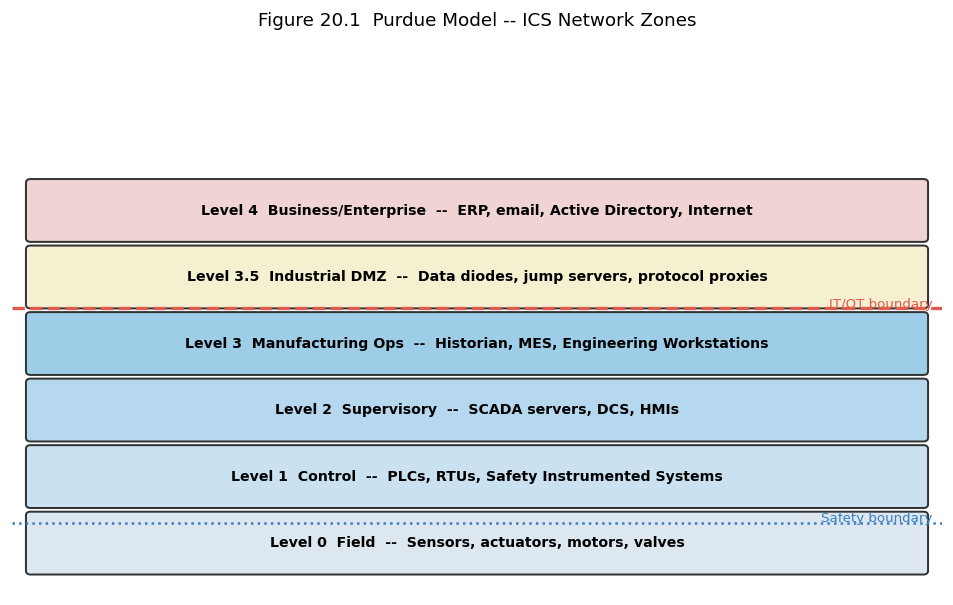

Figure 20.1 rendered.

=== OT Network Connection Policy Audit ===

  L.Src->L.Dst   Protocol   Status
  ---------------------------------------------------------------------------
  L4->L3         RDP        COMPLIANT
  L3->L4         Modbus     COMPLIANT
  L4->L1         ping       CRITICAL: Direct IT-to-control-level connection bypasses industrial DMZ
  L3->L4         OPC-DA     COMPLIANT
  L2->L4         HTTP       CRITICAL: Direct IT-to-control-level connection bypasses industrial DMZ; WARNING: OT->IT flow should use data diode unless historian replication


In [1]:
# Chapter 20 -- Purdue model zone validator and OT risk scorer

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from io import BytesIO
from IPython.display import display, Image
from dataclasses import dataclass
from typing import List

# ── Purdue Model visualisation ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off"); ax.set_xlim(0, 10); ax.set_ylim(0, 7.5)

levels = [
    ("Level 0  Field",               "Sensors, actuators, motors, valves",          "#dde7f0", 0.3),
    ("Level 1  Control",             "PLCs, RTUs, Safety Instrumented Systems",      "#c9e1f0", 1.2),
    ("Level 2  Supervisory",         "SCADA servers, DCS, HMIs",                    "#b5d8ef", 2.1),
    ("Level 3  Manufacturing Ops",   "Historian, MES, Engineering Workstations",     "#9ecde8", 3.0),
    ("Level 3.5  Industrial DMZ",    "Data diodes, jump servers, protocol proxies",  "#f5f0cf", 3.9),
    ("Level 4  Business/Enterprise", "ERP, email, Active Directory, Internet",       "#f0d4d4", 4.8),
]

for label, components, color, y in levels:
    ax.add_patch(mpatches.FancyBboxPatch((0.2, y), 9.6, 0.75,
                 boxstyle="round,pad=0.05", facecolor=color, edgecolor="#333", lw=1.2))
    ax.text(5.0, y+0.38, f"{label}  --  {components}",
            ha="center", va="center", fontsize=8.5, fontweight="bold")

# Boundary lines
ax.axhline(3.85, color="#e05a4e", lw=2, ls="--")
ax.text(9.9, 3.87, "IT/OT boundary", color="#e05a4e", fontsize=8, ha="right")
ax.axhline(0.95, color="#3a7ebf", lw=1.5, ls=":")
ax.text(9.9, 0.97, "Safety boundary", color="#3a7ebf", fontsize=8, ha="right")

ax.set_title("Figure 20.1  Purdue Model -- ICS Network Zones", fontsize=11, pad=8)

_buf = BytesIO()
plt.savefig(_buf, format="png", dpi=120, bbox_inches="tight")
plt.close(); _buf.seek(0)
display(Image(data=_buf.read()))
print("Figure 20.1 rendered.")

# ── OT zone policy checker ─────────────────────────────────────────────────────
@dataclass
class Connection:
    src_zone: int
    dst_zone: int
    protocol: str
    direction: str
    note: str

def ot_policy_check(conn: Connection) -> str:
    violations = []
    # No direct connection between Level 4 and Level 0-2
    if (conn.src_zone >= 4 and conn.dst_zone <= 2) or \
       (conn.dst_zone >= 4 and conn.src_zone <= 2):
        violations.append("CRITICAL: Direct IT-to-control-level connection bypasses industrial DMZ")
    # Only one-way flows from OT to IT are acceptable for historian data
    if conn.src_zone <= 3 and conn.dst_zone == 4 and "historian" not in conn.note.lower():
        violations.append("WARNING: OT->IT flow should use data diode unless historian replication")
    # No internet-routable protocols in Level 0-3
    if conn.dst_zone <= 3 and conn.protocol in ["HTTP", "SMTP", "FTP"]:
        violations.append("WARNING: IT protocol in OT zone -- verify necessity and implement controls")
    # Level 3.5 must mediate all cross-boundary traffic
    if conn.src_zone == 4 and conn.dst_zone == 3 and "dmz" not in conn.note.lower():
        violations.append("VIOLATION: Level 4 connecting to Level 3 without traversing DMZ (3.5)")
    return "; ".join(violations) if violations else "COMPLIANT"

connections = [
    Connection(4, 3, "RDP",     "->", "Engineer remote access -- should go via jump server in DMZ"),
    Connection(3, 4, "Modbus",  "->", "Historian replication of process data"),
    Connection(4, 1, "ping",    "->", "IT admin checking PLC availability directly"),
    Connection(3, 4, "OPC-DA",  "->", "Historian data via data diode in DMZ"),
    Connection(2, 4, "HTTP",    "->", "HMI software update from internet"),
]

print("\n=== OT Network Connection Policy Audit ===\n")
print(f"  {'L.Src->L.Dst':<14} {'Protocol':<10} {'Status'}")
print("  " + "-"*75)
for c in connections:
    status = ot_policy_check(c)
    print(f"  L{c.src_zone}->L{c.dst_zone}         {c.protocol:<10} {status}")


## Review Questions (MCQ)

**Q1.** In OT environments, the priority ordering of the CIA triad differs from IT in that:
A. Confidentiality takes priority over Availability  B. Availability and Integrity are prioritized over Confidentiality  C. Integrity is irrelevant in OT  D. All three are equally weighted

**Q2.** A PLC (Programmable Logic Controller) is best described as:
A. A network firewall for industrial networks  B. A ruggedised computer executing deterministic control logic for physical actuators  C. A SCADA server  D. A human-machine interface

**Q3.** The Purdue Model Level 3.5 (Industrial DMZ) is designed to:
A. House all PLCs  B. Mediate all traffic between the OT network and the enterprise IT network  C. Replace the air gap entirely  D. Provide internet access to operators

**Q4.** Stuxnet was significant because it:
A. Was the first computer virus  B. Targeted Windows desktop PCs  C. Was the first publicly documented cyberweapon causing physical damage to industrial equipment  D. Attacked internet infrastructure

**Q5.** TRITON/TRISIS was most alarming because it:
A. Encrypted historian data  B. Targeted Safety Instrumented Systems, the last protection layer before physical harm  C. Caused a power blackout  D. Spread via USB drives

**Q6.** Modbus lacks which fundamental security property?
A. Reliability  B. Determinism  C. Authentication  D. Speed

**Q7.** A data diode is used in OT security to:
A. Convert OT protocols to IT protocols  B. Allow network traffic to flow in one direction only  C. Authenticate PLC commands  D. Replace the firewall

**Q8.** IEC 62443 Security Level 4 is designed to protect against:
A. Accidental misconfiguration  B. Script kiddies  C. Nation-state adversaries with sophisticated capabilities  D. Physical theft

**Q9.** The engineering workstation (EWS) is a high-value OT target because:
A. It runs Windows XP  B. It is used to program PLCs and may have connectivity to both IT and OT networks  C. It stores historian data  D. It provides internet access to operators

**Q10.** The most effective compensating control when an OT device cannot be patched is:
A. Ignoring the vulnerability until a maintenance window is available  B. Network segmentation and protocol-aware monitoring to limit exposure and detect exploitation  C. Installing endpoint antivirus  D. Changing the default password

**Q11.** In a Modbus TCP request, the field that establishes that the sender is authorized to issue the command is:
A. The transaction identifier  B. The unit identifier  C. The protocol identifier  D. There is no such field

**Q12.** A layer of protection analysis requires a total risk reduction factor of 25,000. Two independent protection layers, each credited with a factor of 10, already exist. The safety instrumented function must achieve an average probability of failure on demand no worse than:
A. 0.25  B. 0.04  C. 0.004  D. 0.0004

**Q13.** Under NERC CIP-007-6 Requirement R2, an entity that has evaluated a security patch as applicable but cannot install it in the required window may instead:
A. Ignore the patch until the next audit  B. Create a dated mitigation plan or revise an existing one  C. Reclassify the asset as low impact  D. Request a written extension from the vendor

**Q14.** Passive network monitoring on an OT network cannot:
A. Identify device firmware versions  B. Detect an unexpected write command  C. Discover a device that is not transmitting  D. Operate without adding traffic to the network

**Q15.** According to NRC Information Notice 2007-15, the August 2006 manual scram at Browns Ferry Unit 3 was caused by:
A. A targeted cyber attack on the plant network  B. Excessive traffic on the plant network causing the recirculation pump variable frequency drive controllers to malfunction  C. A failed safety instrumented function  D. A security patch applied during operation

*Answers: Q1 B, Q2 B, Q3 B, Q4 C, Q5 B, Q6 C, Q7 B, Q8 C, Q9 B, Q10 B, Q11 D, Q12 C, Q13 B, Q14 C, Q15 B.*


## Lab Assignment

**Part A -- Purdue zone mapping**: For a fictional water treatment plant (control room PCs, 12 PLCs, 3 RTUs at remote pump stations, a SCADA server, a historian, and an enterprise ERP system), map every component to its Purdue level. Identify all data flows between levels and flag any that violate the industrial DMZ principle.

**Part B -- OT risk assessment**: Using the OT connection checker above, add five connections of your own design. For each connection you flag as a violation, propose a compensating control or architecture change that would make it compliant.

**Part C -- Stuxnet case study**: Research the publicly documented technical details of Stuxnet. Write a two-page technical summary covering: initial infection vector, propagation mechanism, PLC targeting logic, the operator-deception technique used to hide the attack, and the three controls that, if in place, might have detected or prevented the attack.

**Part D -- IEC 62443 zone design**: For a chemical plant with three process areas (reaction, separation, storage) and a central control room, design an IEC 62443-compliant zone and conduit model. Specify the security level for each zone, the conduit controls between zones, and justify your security-level assignments.


## References

```{bibliography}
:filter: docname in docnames
```

Primary sources for this chapter, listed so that every date and figure above can be checked against
the document it came from.

1. NIST, *SP 800-82r3: Guide to Operational Technology (OT) Security*, September 2023 (documented
   incidents in Appendix C, scanning guidance in Appendix E).
2. Modbus Organization, *MODBUS Application Protocol Specification V1.1b3*, 26 April 2012; IEEE Std
   1815-2012 Clause 7 (DNP3 Secure Authentication); IANA Service Name and Port Number Registry.
3. IEC 62443-3-3:2013 and ANSI/ISA-62443-3-2-2020; IEC 61511-1 and IEC 61508 for the SIL bands.
4. NERC Reliability Standards CIP-002 through CIP-015, notably CIP-007-6 R2 and CIP-008-6 R4.
5. US NRC, Information Notice 2007-15, *Effects of Ethernet-Based, Non-Safety Related Controls on the
   Safe and Continued Operation of Nuclear Power Stations*, 17 April 2007.
6. Falliere, O Murchu, and Chien, *W32.Stuxnet Dossier*, Symantec, version 1.4, February 2011.
7. E-ISAC and SANS, *Analysis of the Cyber Attack on the Ukrainian Power Grid*, 18 March 2016.
8. CISA, *MAR-17-352-01 HatMan: Safety System Targeted Malware*; FBI Private Industry Notification
   20220324-001 on TRITON, 24 March 2022.
9. Prepared statement of Charles Carmakal, Mandiant, to the US House Committee on Homeland Security,
   9 June 2021 (Colonial Pipeline).
10. Joint advisories CISA AA22-103A (13 April 2022), CISA AA23-335A (2023), and CISA AA26-231A
    (August 2026); FBI and EPA Public Service Announcement on water sector PLCs, 30 July 2026.
11. Schmitt, M. N., ed. (2017). *Tallinn Manual 2.0 on the International Law Applicable to Cyber Operations*. Cambridge University Press, prepared at the invitation of the NATO Cooperative Cyber Defence Centre of Excellence.


```{index} OT, ICS, SCADA, DCS, PLC, RTU, HMI, Engineering Workstation, Purdue Model, Air gap, IEC 62443, Stuxnet
```
